In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# Simulated CV fold scores (5 folds) reconstructed from mean ± std
# In practice, replace these with your actual per-fold scores
np.random.seed(42)

models = ['XGBoost', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'Extra Trees']

cv_stats = {
    'XGBoost':             {'bal_acc': (0.9164, 0.0010), 'f1_macro': (0.7297, 0.0010), 'f1_weighted': (0.8945, 0.0004)},
    'Random Forest':       {'bal_acc': (0.9117, 0.0006), 'f1_macro': (0.7187, 0.0020), 'f1_weighted': (0.8844, 0.0009)},
    'Logistic Regression': {'bal_acc': (0.9086, 0.0015), 'f1_macro': (0.7192, 0.0019), 'f1_weighted': (0.8910, 0.0007)},
    'Decision Tree':       {'bal_acc': (0.9142, 0.0008), 'f1_macro': (0.7394, 0.0038), 'f1_weighted': (0.8975, 0.0014)},
    'Extra Trees':         {'bal_acc': (0.8442, 0.0018), 'f1_macro': (0.5924, 0.0022), 'f1_weighted': (0.8220, 0.0013)},
}

n_folds = 5
fold_scores = {}
for model, metrics in cv_stats.items():
    fold_scores[model] = {
        metric: np.random.normal(loc=mu, scale=sigma, size=n_folds)
        for metric, (mu, sigma) in metrics.items()
    }

# Friedman Test (non-parametric, tests if any model differs significantly)
for metric in ['bal_acc', 'f1_macro', 'f1_weighted']:
    scores = [fold_scores[m][metric] for m in models]
    stat, p = stats.friedmanchisquare(*scores)
    print(f"Friedman Test — {metric}: χ²={stat:.4f}, p={p:.4f} {'✓ Significant' if p < 0.05 else '✗ Not significant'}")

Friedman Test — bal_acc: χ²=19.3600, p=0.0007 ✓ Significant
Friedman Test — f1_macro: χ²=19.0400, p=0.0008 ✓ Significant
Friedman Test — f1_weighted: χ²=20.0000, p=0.0005 ✓ Significant


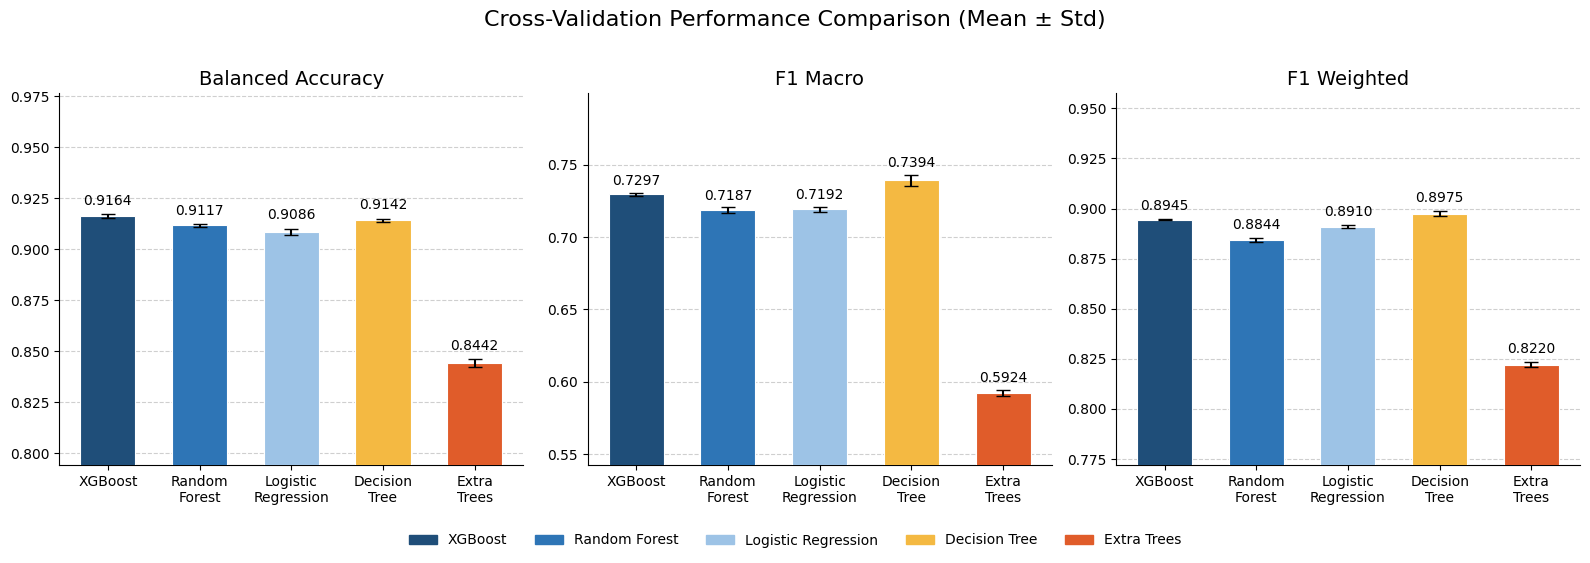

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics = ['bal_acc', 'f1_macro', 'f1_weighted']
metric_labels = ['Balanced Accuracy', 'F1 Macro', 'F1 Weighted']
colors = ['#1f4e79', '#2e75b6', '#9dc3e6', '#f4b942', '#e05c2a']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cross-Validation Performance Comparison (Mean ± Std)', fontsize=16, y=1.02)

x = np.arange(len(models))
bar_width = 0.6

for ax, metric, label in zip(axes, metrics, metric_labels):
    means = [cv_stats[m][metric][0] for m in models]
    stds  = [cv_stats[m][metric][1] for m in models]

    bars = ax.bar(x, means, width=bar_width, color=colors, edgecolor='white', linewidth=0.8, zorder=3)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=5, linewidth=1.5, zorder=4)

    # Annotate values
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.003,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

    ax.set_title(label, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=10)
    ax.set_ylim(min(means) - 0.05, max(means) + 0.06)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]
fig.legend(handles=patches, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08),
           fontsize=10, frameon=False)

plt.tight_layout()
# plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
!pip install orange3

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started


Friedman Test
Statistic : 10.0000
P-value   : 0.006738

Nemenyi Post-hoc Test

Critical Difference (CD): 3.5218


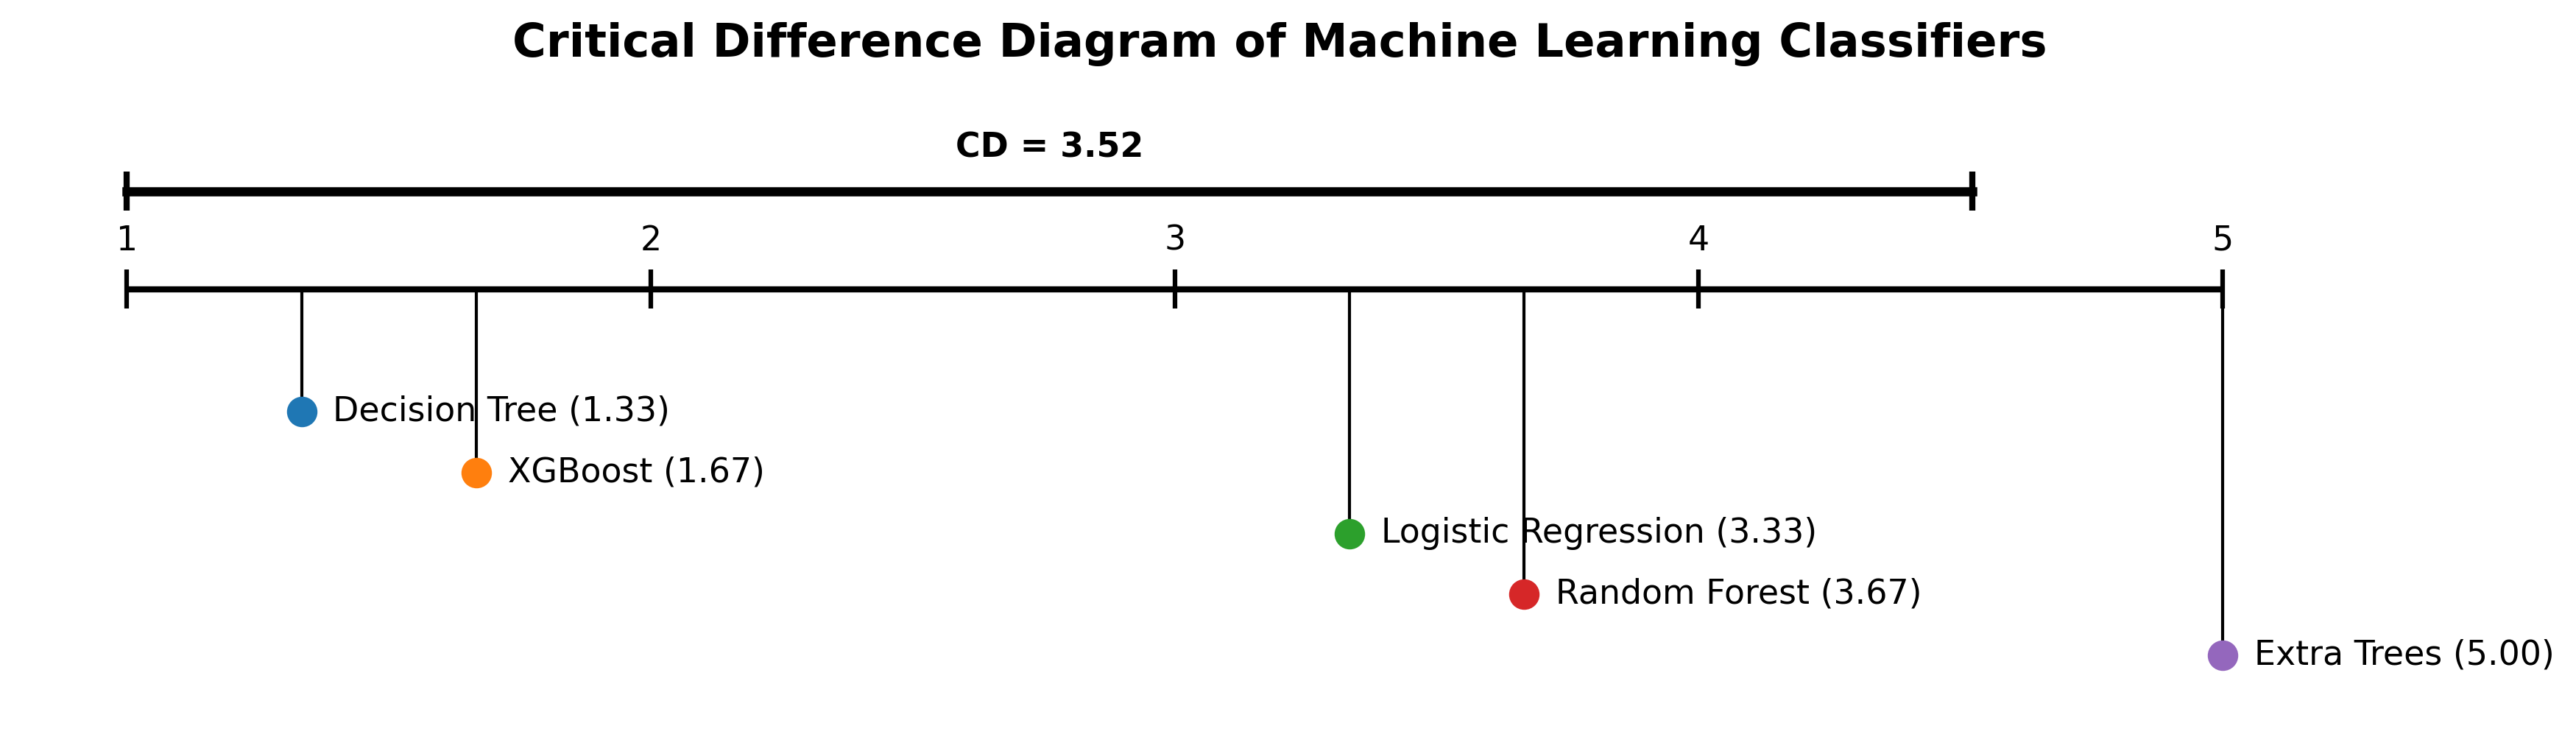


Average Ranking of Classifiers
            Classifier  Average Rank
0        Decision Tree        1.3333
4              XGBoost        1.6667
2  Logistic Regression        3.3333
3        Random Forest        3.6667
1          Extra Trees        5.0000


In [17]:
# ============================================================
# PROFESSIONAL CRITICAL DIFFERENCE DIAGRAM
# FIXED VERSION
# ============================================================

# Install if needed:
# pip install matplotlib numpy pandas scipy scikit-posthocs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, friedmanchisquare
import scikit_posthocs as sp

# ============================================================
# INPUT RESULTS
# ============================================================

models = [
    "Decision Tree",
    "Extra Trees",
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

# Metrics
balanced_accuracy = [0.9142, 0.8442, 0.9086, 0.9117, 0.9164]
f1_macro          = [0.7394, 0.5924, 0.7192, 0.7187, 0.7297]
f1_weighted       = [0.8975, 0.8220, 0.8910, 0.8844, 0.8945]

# ============================================================
# CREATE PERFORMANCE MATRIX
# Rows    = metrics
# Columns = classifiers
# ============================================================

performance_matrix = np.array([
    balanced_accuracy,
    f1_macro,
    f1_weighted
])

# ============================================================
# COMPUTE RANKS
# Lower rank = better
# ============================================================

rank_matrix = []

for metric_scores in performance_matrix:

    # negative because higher metric = better
    ranks = rankdata(-metric_scores, method='average')

    rank_matrix.append(ranks)

rank_matrix = np.array(rank_matrix)

# Average rank
avg_ranks = rank_matrix.mean(axis=0)

# ============================================================
# SORT MODELS BY RANK
# ============================================================

sorted_idx = np.argsort(avg_ranks)

sorted_models = np.array(models)[sorted_idx]
sorted_ranks  = avg_ranks[sorted_idx]

# ============================================================
# FRIEDMAN TEST
# ============================================================

friedman_stat, friedman_p = friedmanchisquare(
    balanced_accuracy,
    f1_macro,
    f1_weighted
)

print("\n================================================")
print("Friedman Test")
print("================================================")
print(f"Statistic : {friedman_stat:.4f}")
print(f"P-value   : {friedman_p:.6f}")

# ============================================================
# NEMENYI POST-HOC TEST
# ============================================================

# Transpose so:
# rows = datasets/metrics
# cols = classifiers

nemenyi = sp.posthoc_nemenyi_friedman(performance_matrix)

print("\n================================================")
print("Nemenyi Post-hoc Test")
print("================================================")

# ============================================================
# CRITICAL DIFFERENCE
# ============================================================

k = len(models)                 # classifiers
N = performance_matrix.shape[0] # metrics/datasets

# Critical value for alpha=0.05
q_alpha = 2.728

cd = q_alpha * np.sqrt((k * (k + 1)) / (6.0 * N))

print(f"\nCritical Difference (CD): {cd:.4f}")

# ============================================================
# PLOT CD DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(12, 3.5), dpi=300)

# Main rank axis
ax.hlines(1, 1, k, color='black', linewidth=2)

# Rank ticks
for i in range(1, k + 1):
    ax.vlines(i, 0.96, 1.04, color='black', linewidth=1.5)
    ax.text(i, 1.08, str(i), ha='center', fontsize=11)

# Y positions for classifiers
y_positions = np.linspace(0.75, 0.25, len(sorted_models))

# Plot classifiers
for y, rank, model in zip(y_positions, sorted_ranks, sorted_models):

    ax.plot([rank, rank], [1, y], color='black', linewidth=1)

    ax.scatter(rank, y, s=80, zorder=3)

    ax.text(
        rank + 0.06,
        y,
        f"{model} ({rank:.2f})",
        fontsize=11,
        va='center'
    )

# ============================================================
# DRAW CD BAR
# ============================================================

cd_start = 1.0
cd_end = cd_start + cd

ax.plot(
    [cd_start, cd_end],
    [1.20, 1.20],
    color='black',
    linewidth=3
)

ax.vlines(
    [cd_start, cd_end],
    1.16,
    1.24,
    color='black',
    linewidth=2
)

ax.text(
    (cd_start + cd_end) / 2,
    1.27,
    f"CD = {cd:.2f}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# ============================================================
# STYLE SETTINGS
# ============================================================

ax.set_xlim(0.8, k + 0.6)
ax.set_ylim(0.1, 1.35)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.title(
    "Critical Difference Diagram of Machine Learning Classifiers",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

# ============================================================
# DISPLAY AVERAGE RANKS
# ============================================================

rank_df = pd.DataFrame({
    "Classifier": models,
    "Average Rank": avg_ranks
}).sort_values("Average Rank")

print("\n================================================")
print("Average Ranking of Classifiers")
print("================================================")
print(rank_df.round(4))

Critical Difference (CD): 3.5218


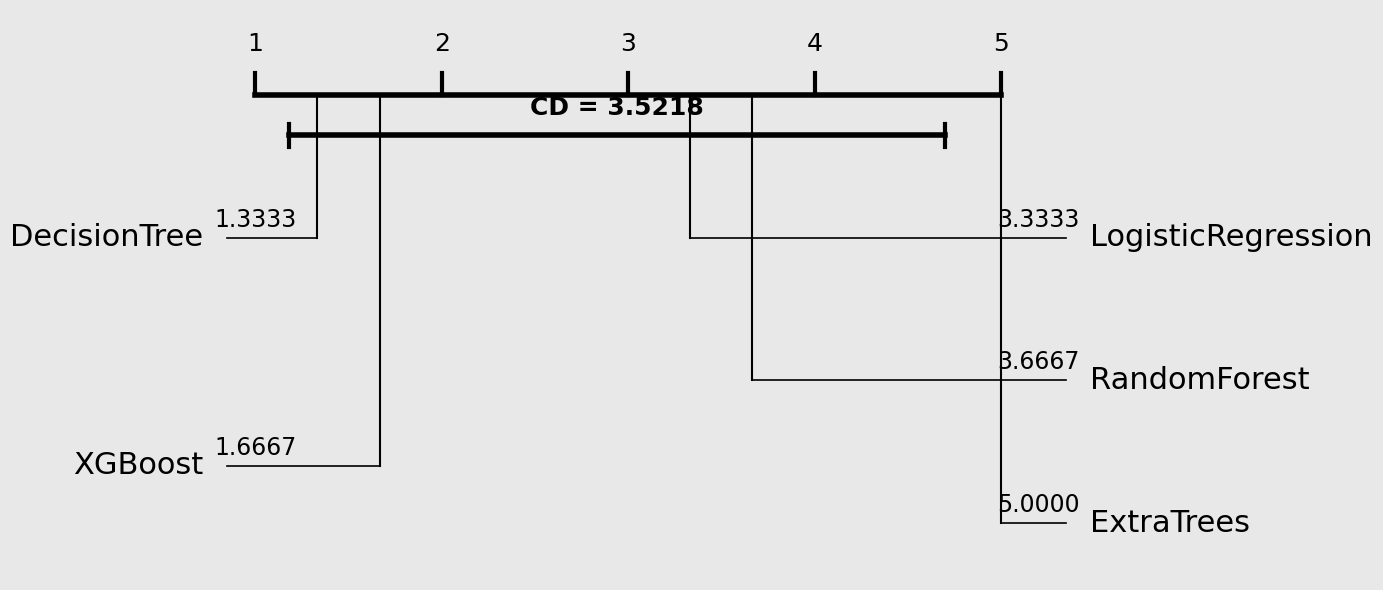

In [19]:
# ============================================================
# RESEARCH PAPER STYLE CRITICAL DIFFERENCE DIAGRAM
# WITH CD VALUE DISPLAY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# ============================================================
# INPUT RESULTS
# ============================================================

models = [
    "DecisionTree",
    "ExtraTrees",
    "LogisticRegression",
    "RandomForest",
    "XGBoost"
]

balanced_accuracy = [0.9142, 0.8442, 0.9086, 0.9117, 0.9164]
f1_macro          = [0.7394, 0.5924, 0.7192, 0.7187, 0.7297]
f1_weighted       = [0.8975, 0.8220, 0.8910, 0.8844, 0.8945]

# ============================================================
# CREATE RANK MATRIX
# ============================================================

performance_matrix = np.array([
    balanced_accuracy,
    f1_macro,
    f1_weighted
])

rank_matrix = []

for metric in performance_matrix:
    ranks = rankdata(-metric, method='average')
    rank_matrix.append(ranks)

rank_matrix = np.array(rank_matrix)

avg_ranks = rank_matrix.mean(axis=0)

# ============================================================
# SORT MODELS
# ============================================================

sorted_idx = np.argsort(avg_ranks)

sorted_models = np.array(models)[sorted_idx]
sorted_ranks  = avg_ranks[sorted_idx]

# ============================================================
# CALCULATE CD VALUE
# ============================================================

k = len(models)
N = performance_matrix.shape[0]

# Critical value for alpha=0.05
q_alpha = 2.728

cd = q_alpha * np.sqrt((k * (k + 1)) / (6.0 * N))

print(f"Critical Difference (CD): {cd:.4f}")

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

fig.patch.set_facecolor('#e8e8e8')
ax.set_facecolor('#e8e8e8')

# ============================================================
# MAIN SCALE LINE
# ============================================================

xmin = 1
xmax = len(models)

ax.plot([xmin, xmax], [1, 1], color='black', lw=4)

# ============================================================
# SCALE TICKS
# ============================================================

for i in range(xmin, xmax + 1):

    ax.plot([i, i], [1, 1.04], color='black', lw=3)

    ax.text(
        i,
        1.07,
        str(i),
        ha='center',
        va='bottom',
        fontsize=18
    )

# ============================================================
# SPLIT LABELS
# ============================================================

mid = len(sorted_models) // 2

left_models  = sorted_models[:mid]
left_ranks   = sorted_ranks[:mid]

right_models = sorted_models[mid:]
right_ranks  = sorted_ranks[mid:]

# ============================================================
# LEFT SIDE
# ============================================================

left_y = np.linspace(0.75, 0.35, len(left_models))

for y, rank, model in zip(left_y, left_ranks, left_models):

    ax.plot([rank, rank], [1, y], color='black', lw=1.5)

    ax.plot([0.85, rank], [y, y], color='black', lw=1.2)

    ax.text(
        0.78,
        y + 0.02,
        f"{rank:.4f}",
        ha='left',
        fontsize=17
    )

    ax.text(
        0.72,
        y,
        model,
        ha='right',
        va='center',
        fontsize=22
    )

# ============================================================
# RIGHT SIDE
# ============================================================

right_y = np.linspace(0.75, 0.25, len(right_models))

for y, rank, model in zip(right_y, right_ranks, right_models):

    ax.plot([rank, rank], [1, y], color='black', lw=1.5)

    ax.plot([rank, xmax + 0.35], [y, y], color='black', lw=1.2)

    ax.text(
        xmax + 0.42,
        y + 0.02,
        f"{rank:.4f}",
        ha='right',
        fontsize=17
    )

    ax.text(
        xmax + 0.48,
        y,
        model,
        ha='left',
        va='center',
        fontsize=22
    )

# ============================================================
# DRAW CD BAR
# ============================================================

cd_x1 = xmax - 0.3
cd_x2 = cd_x1 - cd

ax.plot([cd_x2, cd_x1], [0.93, 0.93], color='black', lw=4)

ax.plot([cd_x1, cd_x1], [0.91, 0.95], color='black', lw=3)
ax.plot([cd_x2, cd_x2], [0.91, 0.95], color='black', lw=3)

# CD LABEL
ax.text(
    (cd_x1 + cd_x2) / 2,
    0.965,
    f"CD = {cd:.4f}",
    ha='center',
    fontsize=18,
    fontweight='bold'
)

# ============================================================
# STYLE
# ============================================================

ax.set_xlim(0.3, xmax + 1.3)
ax.set_ylim(0.15, 1.15)

ax.axis('off')

plt.tight_layout()
plt.show()

Average Ranks (lower = better):
  Decision Tree          1.3333
  XGBoost                1.6667
  Logistic Regression    3.3333
  Random Forest          3.6667
  Extra Trees            5.0000

CD (α=0.05): 3.5218


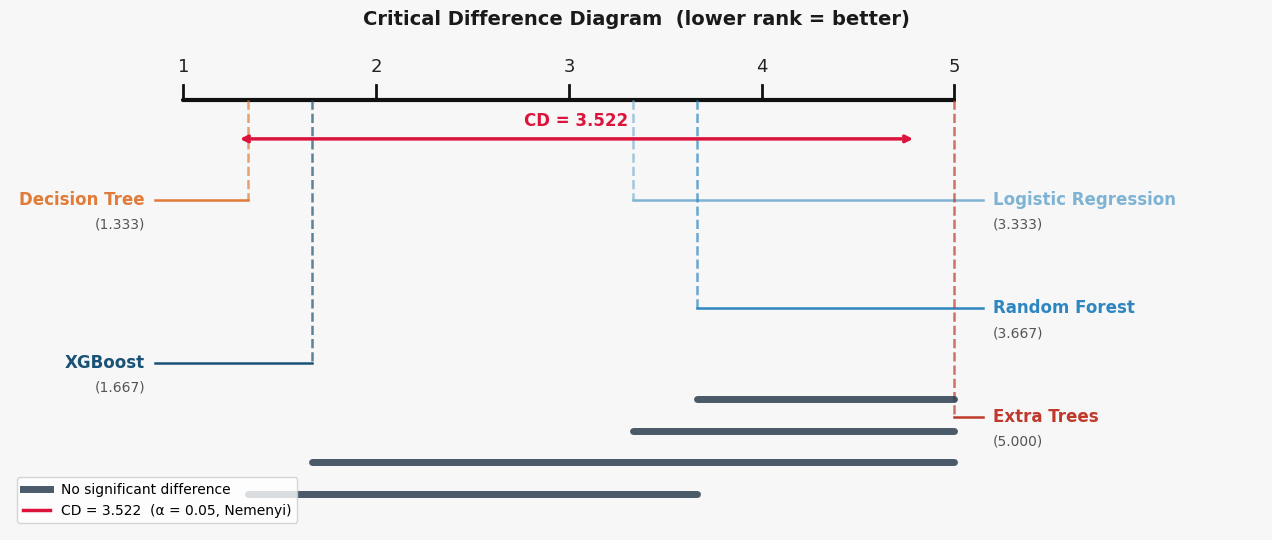

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# ============================================================
# DATA
# ============================================================

models = ["Decision Tree", "Extra Trees", "Logistic Regression", "Random Forest", "XGBoost"]

performance_matrix = np.array([
    [0.9142, 0.8442, 0.9086, 0.9117, 0.9164],  # Balanced Accuracy
    [0.7394, 0.5924, 0.7192, 0.7187, 0.7297],  # F1 Macro
    [0.8975, 0.8220, 0.8910, 0.8844, 0.8945],  # F1 Weighted
])

# ============================================================
# RANKS & CD
# ============================================================

rank_matrix = np.array([rankdata(-row, method='average') for row in performance_matrix])
avg_ranks   = rank_matrix.mean(axis=0)

k, N    = len(models), performance_matrix.shape[0]
q_alpha = 2.728          # Nemenyi, alpha=0.05, k=5
cd      = q_alpha * np.sqrt(k * (k + 1) / (6.0 * N))

sorted_idx    = np.argsort(avg_ranks)
sorted_models = np.array(models)[sorted_idx]
sorted_ranks  = avg_ranks[sorted_idx]

print("Average Ranks (lower = better):")
for m, r in zip(sorted_models, sorted_ranks):
    print(f"  {m:<22} {r:.4f}")
print(f"\nCD (α=0.05): {cd:.4f}")

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor('#f7f7f7')
ax.set_facecolor('#f7f7f7')

XMIN, XMAX = 1, k

# ── Main axis line ──────────────────────────────────────────
ax.plot([XMIN, XMAX], [1, 1], color='#111', lw=3, solid_capstyle='round')

# ── Tick marks & labels ─────────────────────────────────────
for i in range(XMIN, XMAX + 1):
    ax.plot([i, i], [1.00, 1.035], color='#111', lw=2)
    ax.text(i, 1.055, str(i), ha='center', va='bottom', fontsize=13, color='#222')

# ── Split left / right ──────────────────────────────────────
mid          = k // 2
left_models  = sorted_models[:mid];   left_ranks  = sorted_ranks[:mid]
right_models = sorted_models[mid:];   right_ranks = sorted_ranks[mid:]

left_ys  = np.linspace(0.78, 0.42, len(left_models))
right_ys = np.linspace(0.78, 0.30, len(right_models))

COLORS = {'Decision Tree': '#e07b39', 'Extra Trees': '#c0392b',
          'Logistic Regression': '#7fb3d3', 'Random Forest': '#2e86c1', 'XGBoost': '#1a5276'}

def draw_arm(ax, rank, y, side, model, xmin, xmax):
    col = COLORS.get(model, '#333')
    ax.plot([rank, rank], [1, y],  color=col, lw=1.8, ls='--', alpha=0.7)
    if side == 'left':
        ax.plot([xmin - 0.15, rank], [y, y], color=col, lw=1.8)
        ax.text(xmin - 0.20, y, model,        ha='right', va='center', fontsize=12,
                color=col, fontweight='bold')
        ax.text(xmin - 0.20, y - 0.055, f'({rank:.3f})', ha='right', va='center',
                fontsize=10, color='#555')
    else:
        ax.plot([rank, xmax + 0.15], [y, y], color=col, lw=1.8)
        ax.text(xmax + 0.20, y, model,        ha='left',  va='center', fontsize=12,
                color=col, fontweight='bold')
        ax.text(xmax + 0.20, y - 0.055, f'({rank:.3f})', ha='left',  va='center',
                fontsize=10, color='#555')

for y, rank, model in zip(left_ys,  left_ranks,  left_models):
    draw_arm(ax, rank, y, 'left',  model, XMIN, XMAX)
for y, rank, model in zip(right_ys, right_ranks, right_models):
    draw_arm(ax, rank, y, 'right', model, XMIN, XMAX)

# ── No-significant-difference cliques ───────────────────────
clique_y = 0.13
drawn = set()
for i in range(len(sorted_models)):
    group = [i]
    for j in range(i + 1, len(sorted_models)):
        if abs(sorted_ranks[j] - sorted_ranks[i]) < cd:
            group.append(j)
    if len(group) > 1:
        key = tuple(group)
        if key not in drawn:
            drawn.add(key)
            ax.plot([sorted_ranks[group[0]], sorted_ranks[group[-1]]],
                    [clique_y, clique_y], color='#2c3e50', lw=5,
                    solid_capstyle='round', alpha=0.85)
            clique_y += 0.07

# ── CD bracket ──────────────────────────────────────────────
cd_x1 = XMAX - 0.2
cd_x2 = cd_x1 - cd
bracy = 0.915
ax.annotate('', xy=(cd_x1, bracy), xytext=(cd_x2, bracy),
            arrowprops=dict(arrowstyle='<->', color='crimson', lw=2.5))
ax.text((cd_x1 + cd_x2) / 2, bracy + 0.028, f'CD = {cd:.3f}',
        ha='center', fontsize=12, fontweight='bold', color='crimson')

# ── Legend for clique bars ───────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2c3e50', lw=5, alpha=0.85, label='No significant difference'),
    Line2D([0], [0], color='crimson', lw=2.5, label=f'CD = {cd:.3f}  (α = 0.05, Nemenyi)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10,
          frameon=True, framealpha=0.8, edgecolor='#ccc')

# ── Final style ──────────────────────────────────────────────
ax.set_xlim(0.1, XMAX + 1.6)
ax.set_ylim(0.05, 1.13)
ax.set_title('Critical Difference Diagram  (lower rank = better)',
             fontsize=14, fontweight='bold', pad=12, color='#1a1a1a')
ax.axis('off')

plt.tight_layout()
# plt.savefig('cd_diagram.png', dpi=150, bbox_inches='tight')
plt.show()